In [1]:
import math
import numpy as np
import networkx as nx

import matplotlib.pyplot as plt

from src.resource_estimates.hexagonal_hubbard_model import hubbard_model_phase_estimation_resources, hubbard_model_time_evolution_resources

figsz = (8, 8)

In [2]:
def qubitization(U: float, tau: float, Lx: int, Ly: int, eps: float) -> int:
    # Taken from tile trotter paper, only the asymptotically dominant terms
    N = 2*Lx*Ly
    lambd = (3*tau + U/4) * N
    Cs = 20*N - 4
    Cr = 0#32*math.ceil(np.log2(Lx)) + 77
    Cp = 0#46*math.ceil(np.log2(Lx)) + 4*10 + 4 * 40 - (L & (-L)) - 16
    return math.ceil(math.pi*lambd / (2*eps)) * (Cs + 2*Cp + Cr)

def dict_to_t_count(dct: dict) -> int:
    tc = 0
    if "t" in dct.keys():
        tc += dct["t"] 
        
    if "tdg" in dct.keys():
        tc += dct["tdg"] 
        
    if "toffoli" in dct.keys():
        tc += 4*dct["toffoli"]
    return tc
U = 4
tau = 1
x = 0.01

# Hamiltonian evolution:

/home/aftkvantify/lie-algebra-trotterization/src/resource_estimates/rotation_synthesis.py:43: UserWarning: When synthesizing rotation into clifford plus T, this function does not compute the single-qubit clifford count due to arbitrary rotations.
  warnings.warn(


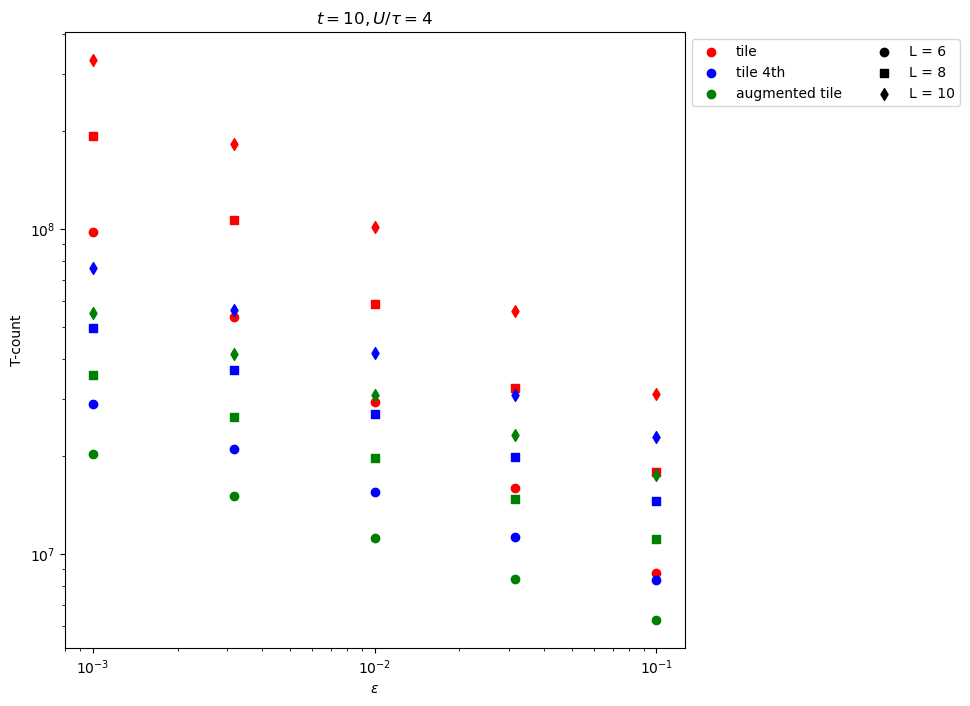

In [3]:
t = 10
logeps_list = np.linspace(-3, -1, 5)
eps_list = np.pow(10, logeps_list)
Ls = [6, 8, 10]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd']
comp_strats = ["tile", "tile 4th", "augmented tile"]

fig, ax = plt.subplots(figsize = figsz)
fig.subplots_adjust(wspace=0, hspace=0)
ax.set_title(rf"$t = {t}, U / \tau = {U}$")
ax.set_xlabel(rf"$\varepsilon$")

for strat, color in zip(comp_strats, colors):
    ax.scatter([],[], c = color, marker = "o", label = strat)

ax.set_ylabel("T-count")
ax.set_xscale("log")
ax.set_yscale("log")
    
for color, comp_strat in zip(colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        dcts = [hubbard_model_time_evolution_resources(
            U,
            tau, 
            L,
            L,
            t,
            e,
            algorithm=comp_strat,
            x=x,
            hwp = 1
        )
            for e in eps_list
        ]
        ys_t = [dict_to_t_count(d) for d in dcts]
        ax.scatter(eps_list, ys_t, marker = marker_style, c = color)

for L, marker in zip(Ls, marker_styles):
    ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")
ax.legend(ncol = 2, loc = "upper left", bbox_to_anchor = (1.0,1.0))

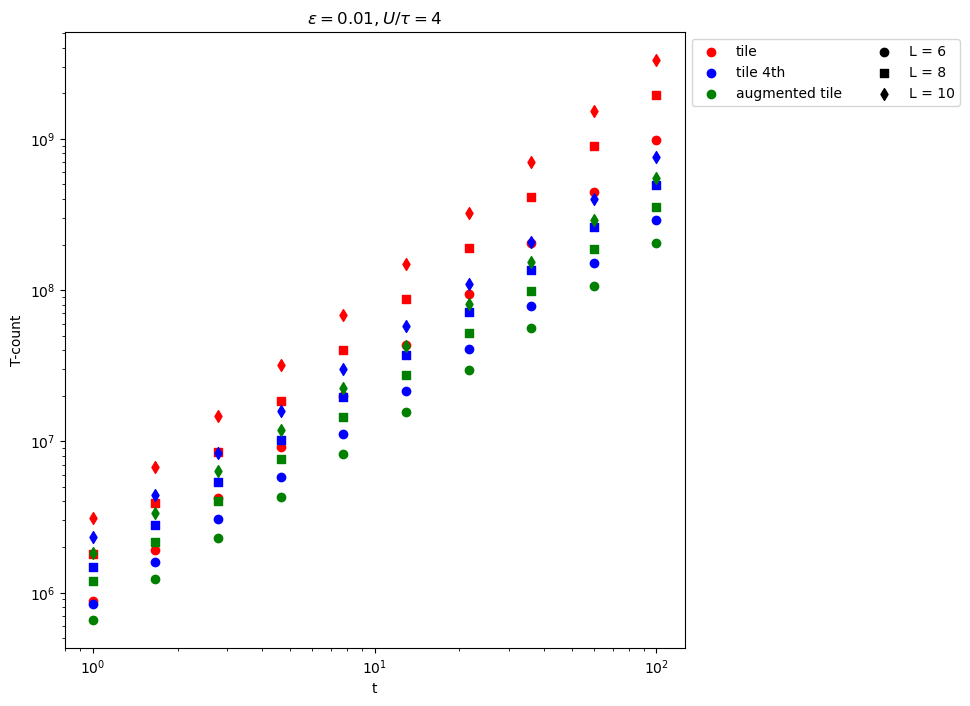

In [4]:
logts = np.linspace(0, 2, 10)
ts = np.pow(10, logts)
eps = 0.01

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd']
comp_strats = ["tile", "tile 4th", "augmented tile"]

fig, ax = plt.subplots(figsize = figsz, sharex = True)
fig.subplots_adjust(wspace=0, hspace=0)
ax.set_title(rf"$\varepsilon = {eps}, U / \tau = {U}$")
ax.set_xlabel(rf"t")

for strat, color in zip(comp_strats, colors):
    ax.scatter([],[], c = color, marker = "o", label = strat)
    
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel("T-count")

for color, comp_strat in zip(colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        dcts = [hubbard_model_time_evolution_resources(
            U,
            tau, 
            L,
            L,
            t,
            eps,
            algorithm = comp_strat,
            x=x,
            hwp = 1
        )
            for t in ts
        ]
        ys_t = [dict_to_t_count(d) for d in dcts]
        ax.scatter(ts, ys_t, marker = marker_style, c = color)
        
for L, marker in zip(Ls, marker_styles):
    ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")
ax.legend(ncol = 2, loc = "upper left", bbox_to_anchor = (1.0,1.0))

# Quantum Phase estimation:

tile
6 [2926837284, 497397434, 84351999, 14422494, 2441744]


/home/aftkvantify/lie-algebra-trotterization/src/resource_estimates/rotation_synthesis.py:43: UserWarning: When synthesizing rotation into clifford plus T, this function does not compute the single-qubit clifford count due to arbitrary rotations.
  warnings.warn(


12 [1936355874, 336941178, 58611701, 10204160, 1793368]
18 [1710604396, 300581376, 52968288, 9332928, 1658758]
tile 4th
6 [1536101012, 351252236, 79449498, 18123730, 4141464]
12 [1020528172, 236781816, 55192280, 12895618, 3011670]
18 [903282394, 212227638, 49940202, 11804016, 2871400]
augmented tile
6 [839321487, 201591642, 48280796, 11779944, 2951344]
12 [586195767, 143199184, 35502080, 9054612, 2429632]
18 [530620152, 131447728, 33201408, 8734266, 2592770]
qubitization
6 [180453504, 57065204, 18046212, 5706664, 1805052]
12 [723321984, 228737684, 72335652, 22874344, 7235292]
18 [1628102784, 514858484, 162818052, 51487144, 16285692]


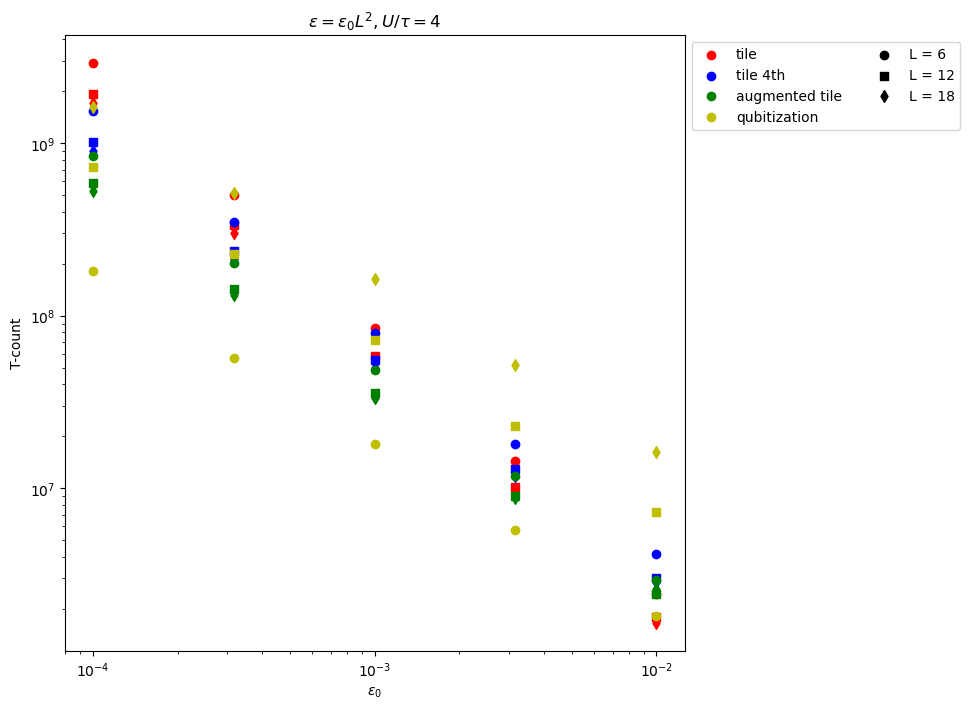

In [3]:
logeps_list = np.linspace(-4, -2, 5)
eps_list = np.pow(10, logeps_list)
Ls = [6, 12, 18]

colors = ['r', 'b', 'g', 'y']
marker_styles = ['o', 's', 'd']
comp_strats = ["tile", "tile 4th", "augmented tile", "qubitization"]
fig, ax = plt.subplots(figsize = figsz, sharex = True)
fig.subplots_adjust(wspace=0, hspace=0)
ax.set_title(rf"$\varepsilon = \varepsilon_0 L^2, U / \tau = {U}$")
ax.set_xlabel(rf"$\varepsilon_0$")

for strat, color in zip(comp_strats, colors):
    ax.scatter([],[], c = color, marker = "o", label = strat)
    
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel("T-count")

for color, comp_strat in zip(colors, comp_strats):
    print(comp_strat)
    for L, marker_style in zip(Ls, marker_styles):
        if comp_strat == "qubitization":
            ys_t = [qubitization(U, tau, L, L, e*L**2) for e in eps_list]
        else:
            dcts = [hubbard_model_phase_estimation_resources(
                U,
                tau,
                L,
                L,
                e*L**2,
                time_evolution_algorithm=comp_strat,
                x = x,
                hwp = 1
            )
                for e in eps_list
                   ]
            ys_t = [dict_to_t_count(d) for d in dcts]
        print(L, ys_t)
        ax.scatter(eps_list, ys_t, marker = marker_style, c = color)
        
for L, marker in zip(Ls, marker_styles):
    ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")
ax.legend(ncol = 2, loc = "upper left", bbox_to_anchor = (1.0,1.0))

In [ ]:
Ls2 = [8, 12, 14, 18]
epss = [0.01, 0.005, 0.001]

colors = ['r', 'b', 'g', 'y']
marker_styles = ['o', 's', 'd']
comp_strats = ["tile", "tile 4th", "augmented tile", "qubitization"]

fig, ax = plt.subplots(figsize = figsz, sharex = True)
fig.subplots_adjust(wspace=0, hspace=0)
ax.set_title(rf"$U / \tau = {U}$")
ax.set_xlabel(rf"L")

for strat, color in zip(comp_strats, colors):
    ax.scatter([],[], c = color, marker = "o", label = strat)

for e, marker in zip(epss, marker_styles):
    ax.scatter([],[], c = "k", marker = marker, label = rf"$\varepsilon = {e}$")
    
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel("T-count")
ax.legend(ncol = 2, loc = "upper left", bbox_to_anchor = (1.0,1.0))
    
for color, comp_strat in zip(colors, comp_strats):
    for e, marker_style in zip(epss, marker_styles):
        if comp_strat == "qubitization":
            ys_t = [qubitization(U,tau, L, L, e) for L in Ls2]
        else:
            dcts = []
            for L in Ls2:
                dcts.append(hubbard_model_phase_estimation_resources(
                    U,
                    tau,
                    L,
                    L,
                    e,
                    time_evolution_algorithm=comp_strat,
                    x = x,
                    hwp = 1
                ))
            ys_t = [dict_to_t_count(d) for d in dcts]
        ax.scatter(Ls2, ys_t, marker = marker_style, c = color)
        